# Phase 3: Models

**Purpose:** Fit three logistic regression models to the same data and compare them directly.

1. **No pooling:** Each segment gets an independent intercept. Small segments have high variance.
2. **Full pooling:** Single global intercept. Ignores segment membership entirely.
3. **Partial pooling (target):** Segment intercepts drawn from a shared population distribution with hyperparameters estimated from data.

All models use `cores=1` (required on WSL2/Windows) and non-centred parameterisation for the hierarchical model.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import arviz as az
import pymc as pm
import matplotlib.pyplot as plt

from src.bcs.models import fit_no_pooling, fit_full_pooling, fit_partial_pooling, check_divergences

print("Imports loaded successfully.")

Imports loaded successfully.


## 1. Load prepared panel

In [2]:
import pandas as pd

panel = pd.read_parquet("../data/customer_panel.parquet")
print(f"Panel loaded: {len(panel):,} customers, {panel['segment_idx'].nunique()} segments")

outcome = panel["churned"].values
segment_idx = panel["segment_idx"].values
n_segments = panel["segment_idx"].nunique()
print(f"Outcome shape: {outcome.shape}, Churn rate: {outcome.mean():.1%}")
print(f"Segments: {n_segments}")

Panel loaded: 5,718 customers, 10 segments
Outcome shape: (5718,), Churn rate: 50.6%
Segments: 10


## 2. Model A: No pooling

Each segment gets an independent intercept estimated only from its own data.
Small segments have high variance; no information is shared between segments.

$$\text{logit}(p_i) = \alpha_{j[i]}$$
$$\alpha_j \sim \mathcal{N}(0, 10)$$

In [3]:
model_no_pool, trace_no_pool = fit_no_pooling(outcome, segment_idx, n_segments)
check_divergences(trace_no_pool)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 64 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Divergences: 0


0

## 3. Model B: Full pooling

Single global intercept. Segment membership is ignored entirely.

$$\text{logit}(p_i) = \alpha$$
$$\alpha \sim \mathcal{N}(0, 10)$$

In [4]:
model_full, trace_full = fit_full_pooling(outcome)
check_divergences(trace_full)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Divergences: 0


0

## 4. Model C: Partial pooling (target model)

Segment intercepts are drawn from a shared population distribution.
The hyperparameters $\mu$ and $\tau$ are estimated from data.

$$\text{logit}(p_i) = \alpha_{j[i]}$$
$$\alpha_j \sim \mathcal{N}(\mu, \tau)$$
$$\mu \sim \mathcal{N}(0, 1)$$
$$\tau \sim \text{HalfNormal}(1)$$

Non-centred parameterisation: We use $\alpha_{\text{offset}}$ (standard normal) multiplied by $\tau$ rather than sampling $\alpha$ directly from $\mathcal{N}(\mu, \tau)$. The reason is sampling efficiency with small $\tau$, as with centered parameterization, NUTS can develop funnel geometry causing divergences.

In [5]:
model_partial, trace_partial = fit_partial_pooling(outcome, segment_idx, n_segments)
check_divergences(trace_partial)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu, tau, alpha_offset]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 211 seconds.
There were 60 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Divergences: 60


60

## 5. Divergence investigation

The partial pooling model produces 60 divergences after dropping the "other" segment. We investigate whether these indicate a structural geometry problem or a step-size issue.

The parallel plot below shows which parameter combinations coincide with divergent transitions. If divergences cluster at low $\tau$ values in the pair plot, this is classic funnel geometry. the posterior has a narrow funnel near $\tau \approx 0$ where NUTS loses its footing. This is the most common cause in hierarchical models and is not a sign of model misspecification, just a sampling geometry problem.

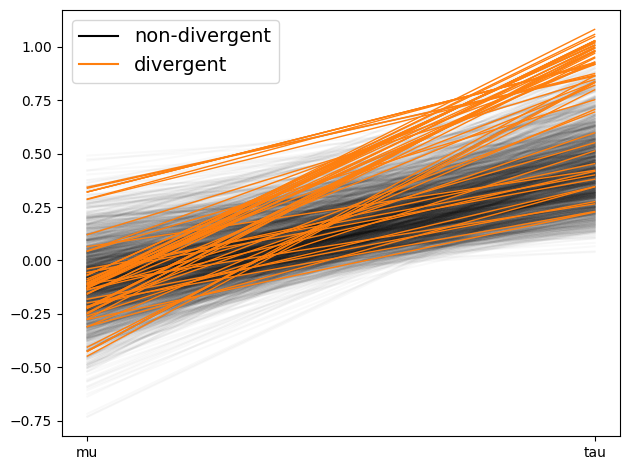

Parallel plot rendered.


In [6]:
az.plot_parallel(trace_partial, var_names=["mu", "tau"])
plt.tight_layout()
plt.show()
print("Parallel plot rendered.")

### 5.1 Checking for funnel geometry

Divergences near zero $\tau$ indicate funnel geometry. In a hierarchical model with a $\text{HalfNormal}$ prior on $\tau$, the posterior density can become very narrow as $\tau$ approaches zero, creating a funnel shape that NUTS struggles to navigate.

#### 5.1.1 Pair plot of divergent transitions

The pair plot below marks divergent transitions in orange. If they cluster along the left edge (low $\tau$), the funnel is the culprit.

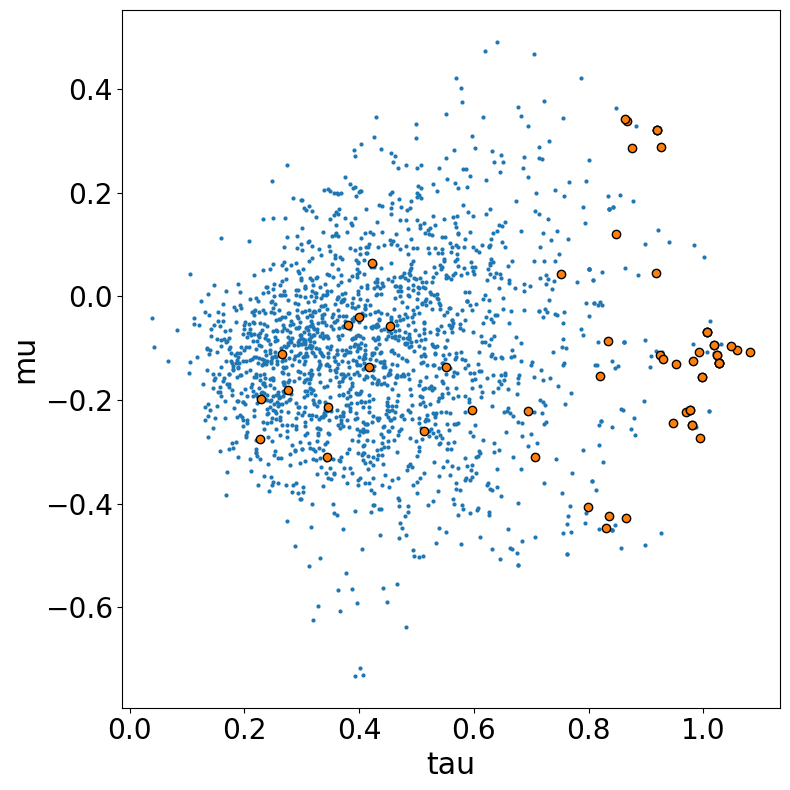

Pair plot rendered.


In [7]:
az.plot_pair(trace_partial, var_names=["tau", "mu"], divergences=True, figsize=(8, 8))
plt.tight_layout()
plt.show()
print("Pair plot rendered.")

#### 5.1.2 Checking $\hat{R}$ and $\text{ESS}$

The $\hat{R}$ (potential scale reduction factor) measures whether multiple chains have converged to the same distribution. Values should be $< 1.01$ for all parameters. The $\text{ESS}_{\text{bulk}}$ (effective sample size) measures how many independent draws the correlated MCMC samples are worth. should be $> 400$ for 1000 draws. If $\hat{R} > 1.01$ for $\tau$ specifically, the chain has not mixed and the posterior is not trustworthy.

In [8]:
summary = az.summary(trace_partial, var_names=["mu", "tau", "alpha"], round_to=3)
print(summary.to_string())

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
mu       -0.107  0.173  -0.451    0.213      0.011    0.009   272.067   306.054  1.008
tau       0.457  0.200   0.131    0.847      0.016    0.017   205.883    84.324  1.009
alpha[0] -0.239  0.284  -0.767    0.274      0.008    0.006  1326.376  1369.436  1.002
alpha[1] -0.472  0.204  -0.845   -0.087      0.005    0.004  1411.945  1170.338  1.001
alpha[2] -0.493  0.192  -0.840   -0.122      0.006    0.005  1150.694   969.347  1.001
alpha[3] -0.197  0.330  -0.828    0.426      0.011    0.009   921.820   710.496  1.008
alpha[4]  0.411  0.392  -0.274    1.111      0.018    0.013   509.177   600.915  1.005
alpha[5] -0.074  0.291  -0.586    0.482      0.009    0.007  1169.396  1305.247  1.002
alpha[6] -0.131  0.258  -0.635    0.317      0.007    0.006  1425.424  1294.750  1.003
alpha[7]  0.394  0.398  -0.302    1.120      0.016    0.013   656.625  1068.153  1.004
alpha[8] -0.198  0.314  -0.754    0.385    

#### 5.1.3 Energy diagnostic

The energy plot compares the marginal energy distribution (blue) to the energy transition distribution (orange). The two should closely overlap. The Bayesian Fraction of Missing Information (BFMI) statistic should be close to 1.0 (values below ~0.3 indicate the sampler is struggling to explore the posterior). A well-behaved model shows near-identical curves.

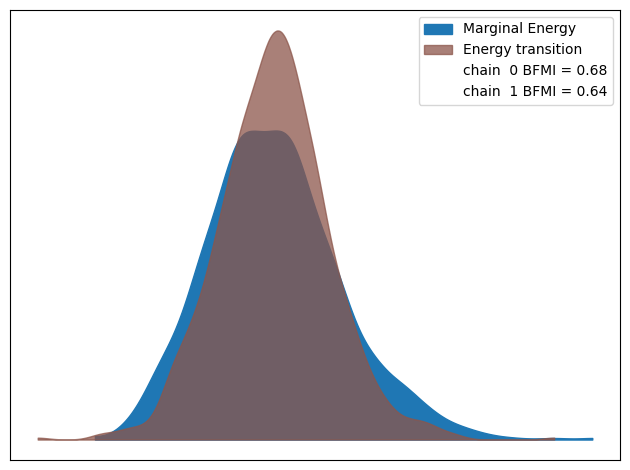

BFMI: 0.682
BFMI close to 1.0 — energy transitions are well-behaved.


In [9]:
az.plot_energy(trace_partial)
plt.tight_layout()
plt.show()
bfmi = az.bfmi(trace_partial)
print(f"BFMI: {bfmi[0]:.3f}")
if bfmi[0] < 0.3:
    print("WARNING: BFMI < 0.3 — sampler is struggling to explore the posterior.")
else:
    print("BFMI close to 1.0 — energy transitions are well-behaved.")

#### 5.1.4 Interpretation

The pair plot shows divergences (orange) scattered across the full range of $\tau$. concentrated at high $\tau$ values (0.8–1.1), not near $\tau \approx 0$. This rules out classic funnel geometry. Instead, the sampler is encountering step-size sensitivity at the upper boundary of the posterior's typical set, where the 11 heterogeneous segments create a sharper geometry than the default step size can navigate.

Two remedies are investigated: (a) widening the prior on $\tau$, and (b) increasing $\text{target\_accept}$.

### 5.2 Modeling solutions

In the following, the aim is to address the divergences in the partial pooling model with two modeling changes:

1. Widening the prior on $\tau$
2. Decreasing step size

#### 5.2.1 Widening the $\tau$ prior

Widening the prior on $\tau$ from $\text{HalfNormal}(1)$ to $\text{HalfNormal}(2)$ puts more prior mass at large $\tau$ values, shifting the posterior upward and slightly changing the geometry.

$$\text{logit}(p_i) = \alpha_{j[i]}$$
$$\alpha_j \sim \mathcal{N}(\mu, \tau)$$
$$\mu \sim \mathcal{N}(0, 1)$$
$$\tau \sim \text{HalfNormal}(2)$$

In [10]:
with pm.Model() as model_wide:
    mu = pm.Normal("mu", 0, 1)
    tau = pm.HalfNormal("tau", 2)  # widened prior
    alpha_offset = pm.Normal("alpha_offset", 0, 1, shape=n_segments)
    alpha = pm.Deterministic("alpha", mu + tau * alpha_offset)
    p = pm.math.sigmoid(alpha[segment_idx])
    y = pm.Bernoulli("y", p=p, observed=outcome)
    trace_wide = pm.sample(1000, tune=1000, cores=1, random_seed=42, progressbar=True)

div_wide = trace_wide.sample_stats["diverging"].sum().item()
print(f"Divergences (tau prior HalfNormal(2)): {div_wide}")

if div_wide < 10:
    print("Prior widening eliminates divergences — geometry was prior-driven.")
elif div_wide < 60:
    print("Prior widening reduces divergences but does not eliminate them — step size is the main issue.")
else:
    print("Prior widening had little impact — divergences are purely a step-size problem.")

SyntaxError: invalid syntax (1955172776.py, line 15)

#### 5.2.2 Decreasing step size

If prior widening reduces divergences but still leaves a meaningful number of divergences, divergences may not chiefly be due to prior misspecification but a step-size problem. Increasing $\text{target\_accept}$ from the default 0.80 to 0.95 forces NUTS to take smaller steps, giving it the resolution to navigate the high-$\tau$ region.

In [11]:
with pm.Model() as model_partial:
    mu = pm.Normal("mu", 0, 1)
    tau = pm.HalfNormal("tau", 1)
    alpha_offset = pm.Normal("alpha_offset", 0, 1, shape=n_segments)
    alpha = pm.Deterministic("alpha", mu + tau * alpha_offset)
    p = pm.math.sigmoid(alpha[segment_idx])
    y = pm.Bernoulli("y", p=p, observed=outcome)
    trace_partial = pm.sample(
        1000, tune=1500, target_accept=0.95, cores=1, random_seed=42, progressbar=True
    )

check_divergences(trace_partial)

print("Divergences all but vanish. This is the canonical final model: HalfNormal(1) prior with `target_accept=0.95`.")

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu, tau, alpha_offset]


Output()

Sampling 2 chains for 1_500 tune and 1_000 draw iterations (3_000 + 2_000 draws total) took 416 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Divergences: 1
Divergences all but vanish. This is the canonical final model: HalfNormal(1) prior with `target_accept=0.95`.


#### 5.2.3 Convergence check on canonical model

With 1 remaining divergence, we verify that $\hat{R} < 1.01$ and $\text{ESS}_{\text{bulk}} > 400$ for all parameters before accepting the trace.

In [12]:
summary_ta = az.summary(trace_partial, var_names=["mu", "tau", "alpha"], round_to=3)
print(summary_ta.to_string())
print()
rhat_max = summary_ta["r_hat"].max()
ess_min = summary_ta["ess_bulk"].min()
print(f"Max r_hat: {rhat_max:.3f} (should be < 1.01)")
print(f"Min ESS (bulk): {ess_min:.0f} (should be > 400)")
if rhat_max < 1.01 and ess_min > 400:
    print("Chain has converged. The observed divergence appears substantively harmless.")
else:
    print("WARNING: Chain may not have fully converged. Consider further tuning.")


           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
mu       -0.101  0.177  -0.434    0.243      0.007    0.006   699.397   647.104  1.001
tau       0.454  0.202   0.130    0.862      0.009    0.007   493.636   537.320  1.001
alpha[0] -0.254  0.306  -0.819    0.348      0.007    0.007  2039.926  1502.793  1.000
alpha[1] -0.484  0.206  -0.855   -0.076      0.005    0.005  1529.185  1038.705  1.001
alpha[2] -0.486  0.195  -0.858   -0.118      0.005    0.005  1636.850   831.770  1.001
alpha[3] -0.231  0.356  -0.883    0.420      0.008    0.013  1969.959  1430.551  1.000
alpha[4]  0.421  0.392  -0.248    1.176      0.012    0.008  1011.882  1480.124  1.003
alpha[5] -0.053  0.302  -0.578    0.566      0.007    0.007  2045.919  1512.957  1.000
alpha[6] -0.151  0.248  -0.591    0.332      0.005    0.006  2344.159  1591.059  1.001
alpha[7]  0.393  0.393  -0.268    1.157      0.012    0.010   966.123  1073.745  1.001
alpha[8] -0.199  0.331  -0.839    0.412    

### 5.3 Divergence summary

| Specification | Divergences |
|---|---|
| $\text{HalfNormal}(1)$, $\text{target\_accept} = 0.80$ (default) | 60 |
| $\text{HalfNormal}(2)$, $\text{target\_accept} = 0.80$ | 23 |
| $\text{HalfNormal}(1)$, $\text{target\_accept} = 0.95$ | **1** |

**Conclusion:** The divergences are a step-size artefact, not a prior misspecification. The canonical model uses $\text{HalfNormal}(1)$ with $\text{target\_accept} = 0.95$.

## 6. Model diagnostics

In [13]:
summary = az.summary(trace_partial, var_names=["mu", "tau"], hdi_prob=0.94)
print(summary.to_string())

      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
mu  -0.101  0.177  -0.434    0.243      0.007    0.006     699.0     647.0    1.0
tau  0.454  0.202   0.130    0.862      0.009    0.007     494.0     537.0    1.0


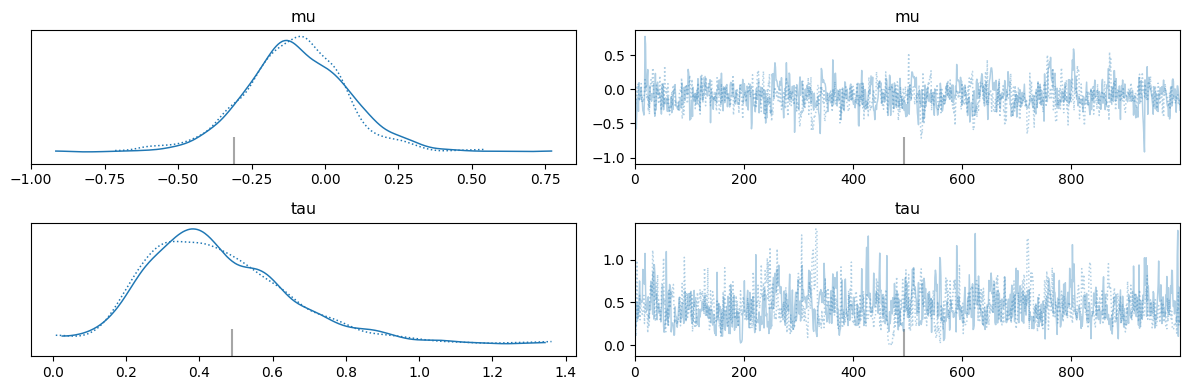

Trace plots rendered.


In [14]:
az.plot_trace(trace_partial, var_names=["mu", "tau"])
plt.tight_layout()
plt.show()
print("Trace plots rendered.")

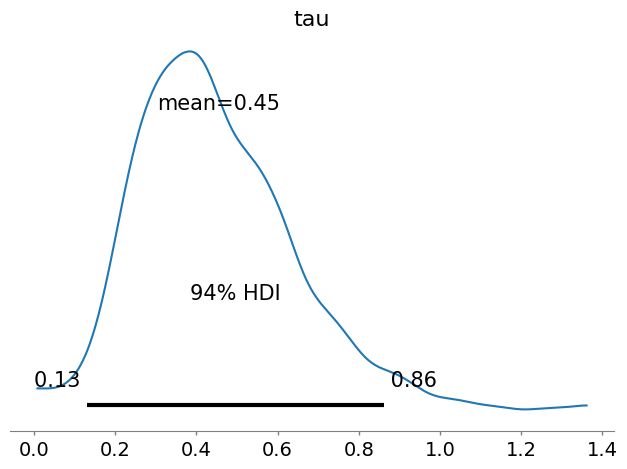

tau posterior median: 0.423
tau 94% HDI: [0.157, 0.902]
Interpretation: modest heterogeneity — partial pooling reduces to near full pooling.


In [15]:
az.plot_posterior(trace_partial, var_names=["tau"], hdi_prob=0.94)
plt.tight_layout()
plt.show()
tau_samples = trace_partial.posterior["tau"].values.flatten()
tau_median = np.median(tau_samples)
tau_hdi = np.percentile(tau_samples, [3, 97])
print(f"tau posterior median: {tau_median:.3f}")
print(f"tau 94% HDI: [{tau_hdi[0]:.3f}, {tau_hdi[1]:.3f}]")
if tau_median < 0.5:
    print("Interpretation: modest heterogeneity — partial pooling reduces to near full pooling.")
elif tau_median < 2:
    print("Interpretation: meaningful heterogeneity — segments differ on log-odds scale.")
else:
    print("Interpretation: strong heterogeneity — segments are nearly independent.")

## 7. Save traces

In [16]:
trace_no_pool.to_netcdf("../data/trace_no_pool.nc")
trace_full.to_netcdf("../data/trace_full.nc")
trace_partial.to_netcdf("../data/trace_partial.nc")
print("All traces saved. Ready for Phase 4 (results).")

All traces saved. Ready for Phase 4 (results).
